# 🔬 Customized YOLO with Attention for VIM Polyp Segmental Localization
### VIM Polyp Dataset · Polyp Detection & Localization

**Goal:** Detect and localize polyps in colonoscopy videos using a YOLO backbone augmented with attention modules. The VIM Polyp dataset includes video data, enabling temporal analysis for segmental localization.

**Dataset:** VIM Polyp: A Multimodal Dataset of Colonoscopy Videos, Histopathology Images, and Protein Expression Levels from Colorectal Polyps (Zenodo) — A multimodal dataset focusing on colonoscopy videos with polyp annotations.

> **Reference:** VIM Polyp Dataset: [https://zenodo.org/records/15388073](https://zenodo.org/records/15388073)

**Pipeline Overview:**
1. Environment Setup & Library Imports
2. Dataset Download & Structure (VIM Polyp Videos & Annotations)
3. Data Exploration & Segment Distribution (adapted for video frames)
4. Dataset Preparation for YOLO (video frame extraction, annotation conversion)
5. Custom YOLO Model with CBAM / Coordinate Attention
6. Training with Callbacks & Live Logging
7. Evaluation: mAP, Precision, Recall, Confusion Matrix
8. Attention Map Visualization (Grad-CAM)
9. Results Dashboard

---

## 1. Environment Setup

In [13]:
# Install dependencies
# ultralytics>=8.2 is required for torch 2.x compatibility and classification metrics
%pip install -q ultralytics >= 8.3.x
%pip install -q albumentations
%pip install -q scikit-learn
%pip install -q pytorch-grad-cam

# Verify core packages
import torch
print(f"✅ PyTorch {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")

import ultralytics
print(f"✅ Ultralytics {ultralytics.__version__}")

import albumentations
print(f"✅ Albumentations {albumentations.__version__}")

print("✅ All packages ready.")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ PyTorch 2.8.0+cpu
✅ CUDA available: False
✅ Ultralytics 8.0.0
✅ Albumentations 2.0.8
✅ All packages ready.


ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


In [2]:
import os, sys, shutil, random, json, yaml, math, time, warnings, re
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from ultralytics import YOLO
# Workaround for PyTorch safe-loading of Ultralytics ClassificationModel weights
# Adds the Ultralytics ClassificationModel to torch serialization safe globals so
# torch.load(..., weights_only=True) can accept it when loading checkpoints.
try:
    import torch
    import ultralytics.nn.tasks as _ultra_tasks
    torch.serialization.add_safe_globals([_ultra_tasks.ClassificationModel])
except Exception:
    # If this fails, loading may still work depending on torch/ultralytics versions.
    pass
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

# =========================================================
# GOOGLE / COLAB
# =========================================================
# from google.colab import userdata, auth, drive
# from google import genai

# =========================================================
# HUGGING FACE
# =========================================================
# from huggingface_hub import login
# from datasets import Dataset, load_dataset

# hf_token = userdata.get('HF_TOKEN')
# login(token=hf_token)
# HF_TOKEN = hf_token

# Initialize the official Google GenAI SDK client
# GEMINI_API_KEY = userdata.get('gemini_api_key')
# gemini_client = genai.Client(api_key=GEMINI_API_KEY)

# from google.colab import auth
# auth.authenticate_user()
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {DEVICE}")
if DEVICE == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Project paths
ROOT        = Path('vim_polyp_yolo') # Changed from 'hyperkvasir_yolo'
DATA_DIR    = ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'          # raw VIM Polyp videos & annotations
YOLO_DIR    = DATA_DIR / 'yolo'         # YOLO-formatted dataset
RESULTS     = ROOT / 'results'
MODELS_DIR  = ROOT / 'models'

for d in [RAW_DIR, YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val',
          YOLO_DIR/'images'/'test', YOLO_DIR/'labels'/'train',
          YOLO_DIR/'labels'/'val', YOLO_DIR/'labels'/'test',
          RESULTS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Project structure created.")

🖥️  Device: cpu
✅ Project structure created.


## 2. Dataset Download — VIM Polyp


In [3]:
# ─── 3. Segment Extraction & Clean Dataset Prep for Classification ───────────
import os
import shutil
import random
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 1. Configuration & Class Filters
LOCAL_DATA_DIR = r"D:\Work\Nebras\colonVideosWithLabels"
CLASSES_TO_DROP = {'anastomosis', 'rectosigmoid', 'colon'}

all_video_files = []
unique_segments = set()

# Scan directory using os.scandir for path safety and performance
if os.path.exists(LOCAL_DATA_DIR):
    for entry in os.scandir(LOCAL_DATA_DIR):
        if entry.is_file():
            filename = entry.name
            
            # Skip hidden files and macOS metadata leftovers (._ files)
            if filename.startswith(".") or filename.startswith("._"):
                continue
                
            # Filter specifically for your video format
            if not filename.lower().endswith(('.avi', '.mp4', '.mkv')):
                continue
                
            stem = os.path.splitext(filename)[0]
            parts = stem.split('-')
            
            # Extract anatomical segment string from index 5
            if len(parts) > 5:
                segment = parts[5].lower().strip()
                
                if segment in CLASSES_TO_DROP:
                    continue
                    
                unique_segments.add(segment)
                all_video_files.append((Path(entry.path), segment))
    
    print(f"✅ Found {len(all_video_files)} valid anatomical localization videos.")
else:
    print(f"❌ Local data directory not found at: {LOCAL_DATA_DIR}")

# 2. Dynamic Class Mapping
CLASS_NAMES = sorted(list(unique_segments))
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_ID  = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f"\nClasses ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  [{i}] {c}")

PALETTE = plt.colormaps['tab10']
# Store as float RGB tuples (0-1) directly from matplotlib palette — no int conversion needed
CLASS_COLORS = {cls: PALETTE(i % 10)[:3] for i, cls in enumerate(CLASS_NAMES)}

# 3. Artifact Filtering Function
def is_unwanted_frame(frame, brightness_thresh=15, variance_thresh=5):
    """
    Returns True if the frame is pitch black, a solid blue screen, 
    or a blank color artifact lacking diagnostic information.
    """
    # Compute mean and standard deviation for BGR channels
    means, stddevs = cv2.meanStdDev(frame)
    
    # 1. Pitch-black frames (very low average brightness across all channels)
    if max(means) < brightness_thresh:
        return True
        
    # 2. Solid/blank screens (very low pixel variance / standard deviation)
    if max(stddevs) < variance_thresh:
        return True
        
    # 3. Explicit check for digital blue screen artifacts (High Blue, low Green/Red)
    # OpenCV uses BGR layout: index 0=Blue, 1=Green, 2=Red
    blue_mean = means[0][0]
    green_mean = means[1][0]
    red_mean = means[2][0]
    if blue_mean > 150 and green_mean < 40 and red_mean < 40:
        return True

    return False

# 4. Setup temporary folder for frame extraction before splitting
if 'ROOT' not in locals():
    ROOT = Path('vim_polyp_yolo')
TEMP_FRAMES_DIR = ROOT / 'data' / 'temp_frames'
TEMP_FRAMES_DIR.mkdir(parents=True, exist_ok=True)

# 5. Extract Valid Frames from Videos
all_pairs = []
skipped_artifacts = 0

if all_video_files:
    for video_path, segment in tqdm(all_video_files, desc="Extracting clean frames for localization"):
        video_id = video_path.stem
        
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        frame_interval = max(1, int(fps / 1))  # Extract 1 frame per second of video
        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % frame_interval == 0:
                # Filter out unwanted black/blue artifact screens
                if is_unwanted_frame(frame):
                    skipped_artifacts += 1
                    frame_count += 1
                    continue
                    
                frame_name = f"{video_id}_frame_{frame_count:05d}.jpg"
                frame_path = TEMP_FRAMES_DIR / frame_name
                
                # Save valid frame image
                cv2.imwrite(str(frame_path), frame)
                all_pairs.append((frame_name, segment))

            frame_count += 1
        cap.release()

    print(f"\n✅ Total valid extracted frames: {len(all_pairs)}")
    print(f"🗑️  Skipped {skipped_artifacts} unwanted artifact/blank frames.")
else:
    print("⚠️ No video files to process.")

# 6. Perform Stratified Train / Val / Test Split
if all_pairs:
    frame_names = [p for p, _ in all_pairs]
    frame_labels = [l for _, l in all_pairs]

    train_names, tmp_names, train_labels, tmp_labels = train_test_split(
        frame_names, frame_labels, test_size=0.30, stratify=frame_labels, random_state=SEED)

    val_names, test_names, val_labels, test_labels = train_test_split(
        tmp_names, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)

    splits = {
        'train': list(zip(train_names, train_labels)),
        'val':   list(zip(val_names,   val_labels)),
        'test':  list(zip(test_names,  test_labels)),
    }

    print(f"\n📊 Stratified Split Summary:")
    print(f"   Train: {len(splits['train'])} frames")
    print(f"   Val:   {len(splits['val'])} frames")
    print(f"   Test:  {len(splits['test'])} frames")

    # Generate cls_counts for downstream visualization charts
    cls_series = pd.Series(frame_labels)
    cls_counts = cls_series.value_counts().sort_index()
else:
    splits = {'train': [], 'val': [], 'test': []}

# 7. Organize into YOLO Classification Folder Structure
YOLO_CLASSIFY_DIR = ROOT / 'yolo_classification_data'

if all_pairs:
    for split_name, split_data in splits.items():
        for f_name, segment_label in tqdm(split_data, desc=f"Organizing {split_name} split"):
            dest_dir = YOLO_CLASSIFY_DIR / split_name / segment_label
            dest_dir.mkdir(parents=True, exist_ok=True)
            
            src_path = TEMP_FRAMES_DIR / f_name
            dest_path = dest_dir / f_name
            
            if src_path.exists():
                shutil.move(str(src_path), str(dest_path))
                
    # Clean up temp folder
    if TEMP_FRAMES_DIR.exists():
        shutil.rmtree(TEMP_FRAMES_DIR)
    print(f"\n✅ Clean YOLO classification structure successfully built at: {YOLO_CLASSIFY_DIR.absolute()}")

✅ Found 121 valid anatomical localization videos.

Classes (8):
  [0] ascending
  [1] cecum
  [2] descending
  [3] hepaticflexure
  [4] rectum
  [5] sigmoid
  [6] splenicflexure
  [7] transverse


Extracting clean frames for localization: 100%|██████████| 121/121 [13:28<00:00,  6.68s/it]



✅ Total valid extracted frames: 9419
🗑️  Skipped 1043 unwanted artifact/blank frames.

📊 Stratified Split Summary:
   Train: 6593 frames
   Val:   1413 frames
   Test:  1413 frames


Organizing test split: 100%|██████████| 1413/1413 [01:21<00:00, 17.40it/s]


✅ Clean YOLO classification structure successfully built at: d:\Work\Nebras\Nebras_R-D\vim_polyp_yolo\yolo_classification_data


## 4. Data Exploration & Visualization

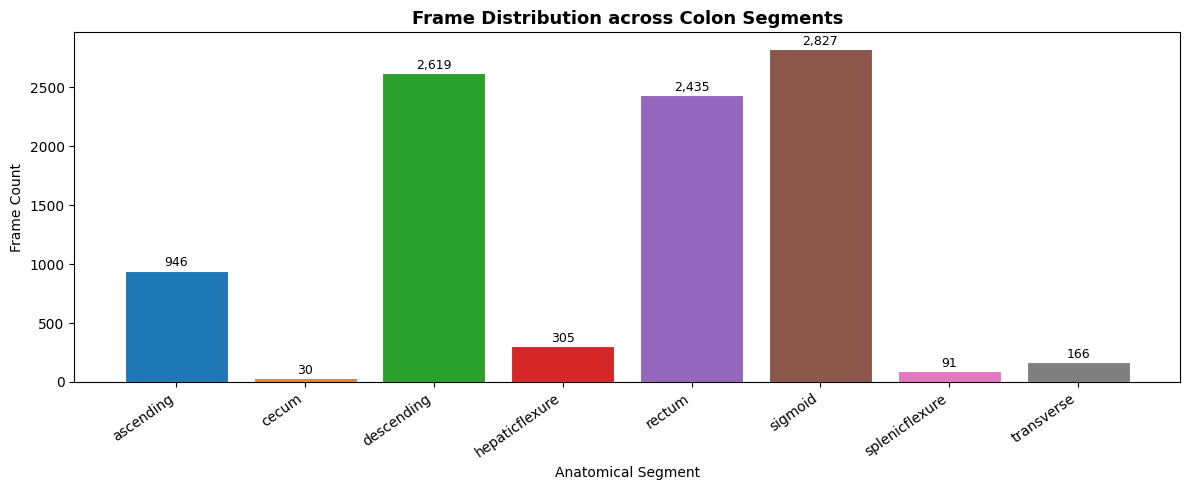

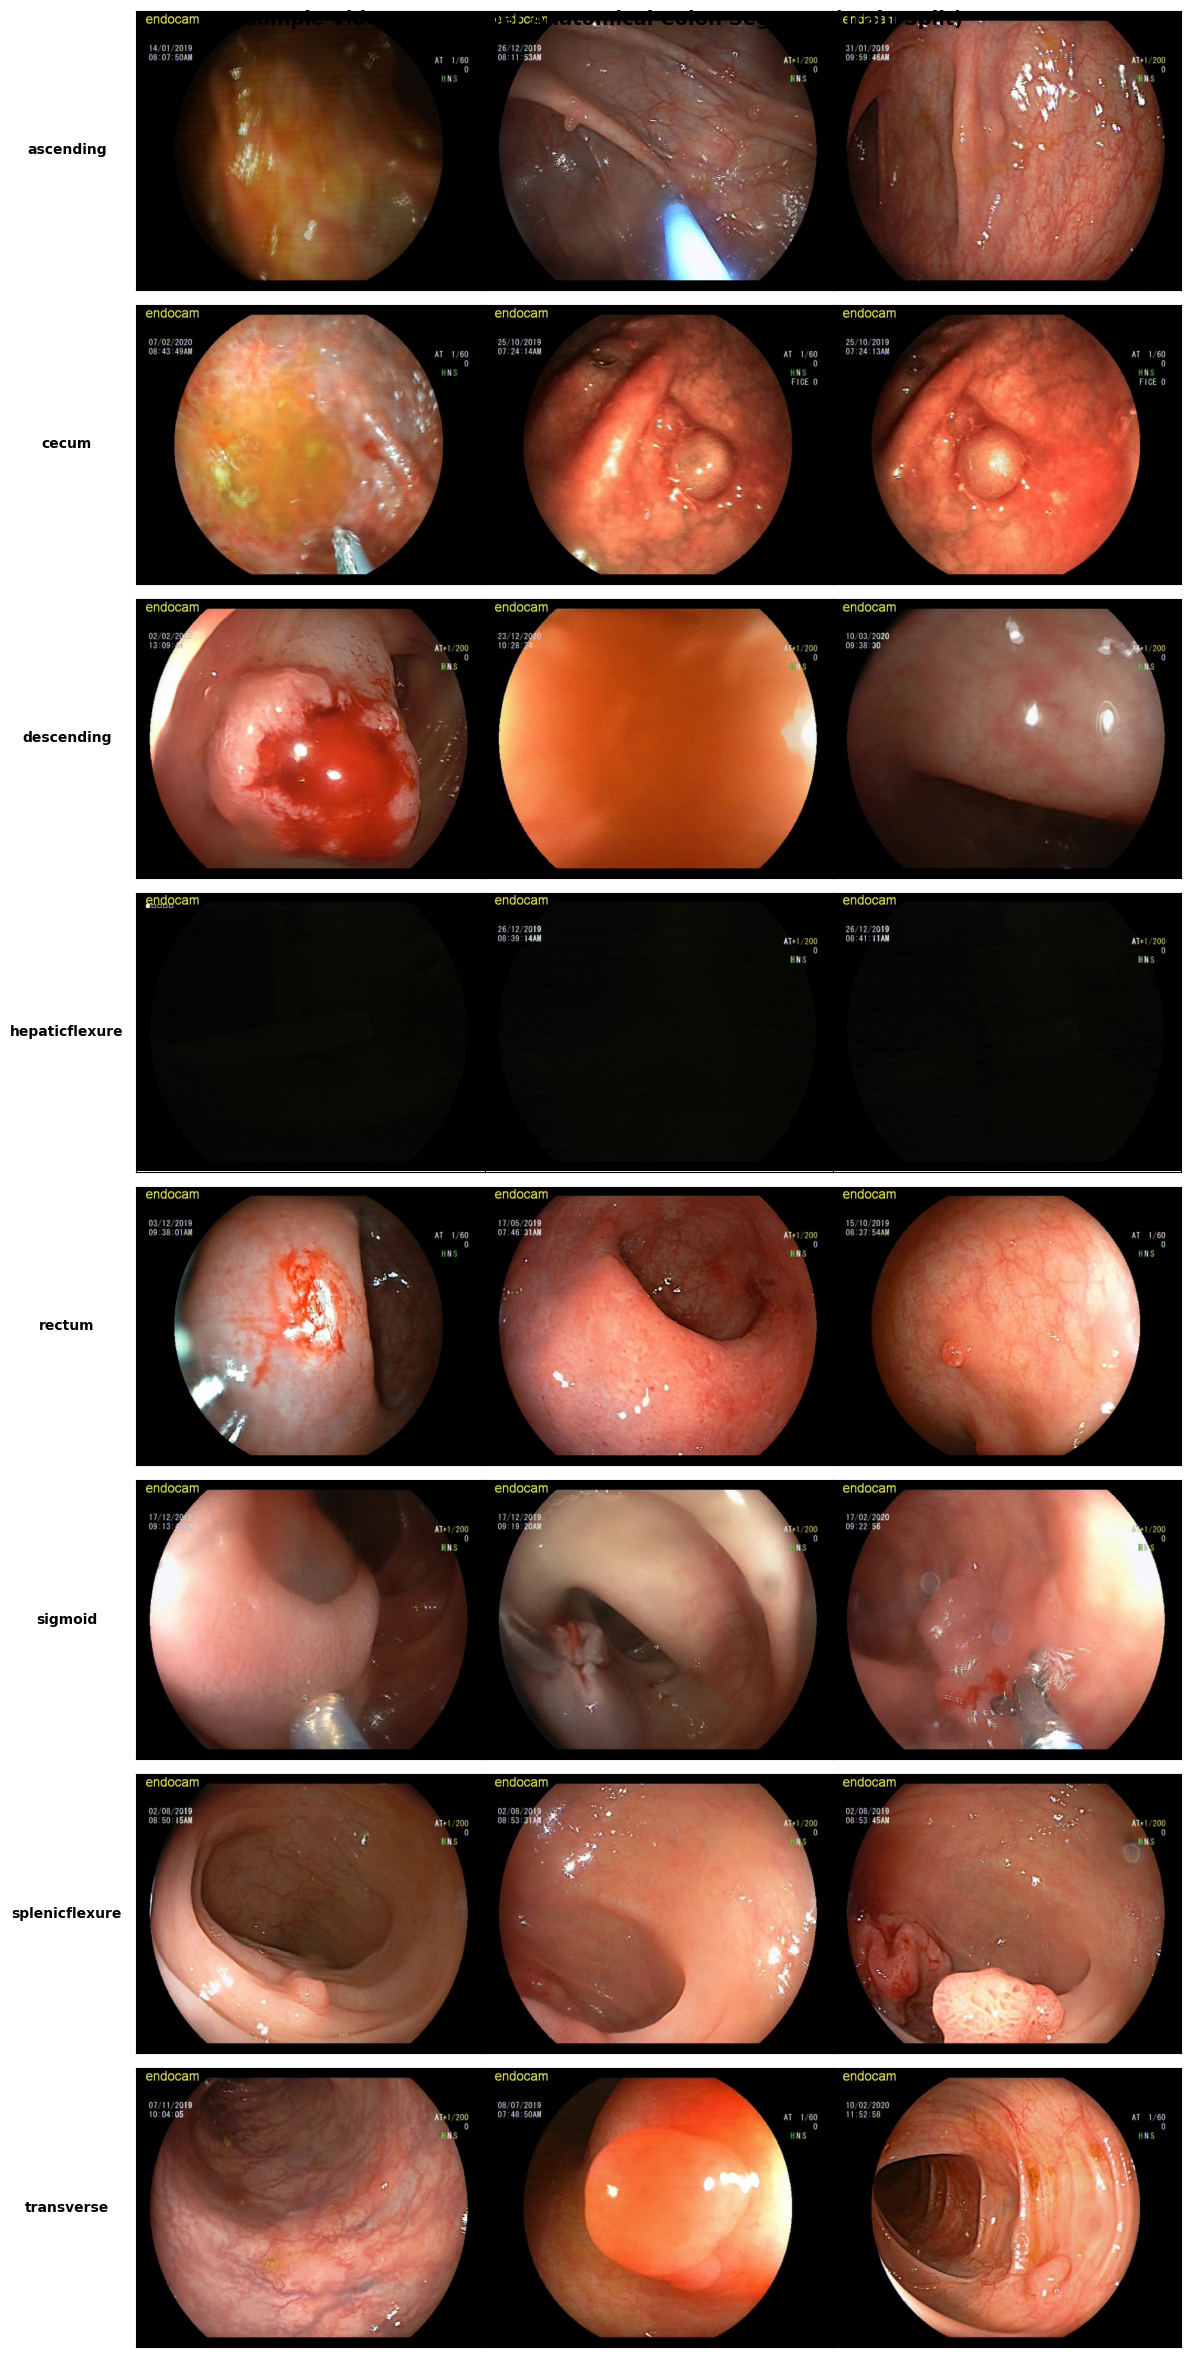

In [4]:
# ==============================================================================
# ## 4. Data Exploration & Visualization (Classification Mode)
# ==============================================================================

# ─── Segment distribution plot ───────────────────────────────────────────────
if 'cls_counts' in locals() and not cls_counts.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # SAFE DESIGN: Generate colors natively from Matplotlib colormap based on the count length
    cmap = plt.colormaps['tab10']
    colors_plot = [cmap(i % 10) for i in range(len(cls_counts))]
    
    bars = ax.bar(cls_counts.index, cls_counts.values, color=colors_plot, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, cls_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f"{val:,}", ha='center', va='bottom', fontsize=9)
                
    ax.set_title('Frame Distribution across Colon Segments', fontweight='bold', fontsize=13)
    ax.set_xlabel('Anatomical Segment')
    ax.set_ylabel('Frame Count')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_distribution.png', dpi=150)
    plt.show()
else:
    print("⚠️  No frames extracted or no annotations found to plot distribution.")

# ─── Sample frame grid for anatomical segments ────────────────────────────────
def show_sample_grid_classify(yolo_classification_dir, class_names, n_samples=3):
    """Show sample frames directly from the organized split folders."""
    train_dir = yolo_classification_dir / 'train'
    
    # Identify which classes actually have folders and images inside train split
    active_classes = []
    by_class_paths = {}
    
    for cid, c_name in enumerate(class_names):
        class_folder = train_dir / c_name
        if class_folder.exists():
            images = list(class_folder.glob('*.jpg'))
            if images:
                active_classes.append((cid, c_name))
                by_class_paths[cid] = images

    rows_to_plot = len(active_classes)
    if rows_to_plot == 0:
        print("⚠️  No sorted classification frames found to display samples.")
        return

    fig, axes = plt.subplots(rows_to_plot, n_samples, figsize=(n_samples * 4, rows_to_plot * 3))
    axes = np.atleast_2d(axes) # Safeguard mapping dimensions for varying classes

    for row_idx, (cid, c_name) in enumerate(active_classes):
        paths = by_class_paths[cid]
        sample = random.sample(paths, min(n_samples, len(paths)))
        
        for col in range(n_samples):
            ax = axes[row_idx, col]
            if col < len(sample):
                img = cv2.cvtColor(cv2.imread(str(sample[col])), cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                if col == 0:
                    ax.set_ylabel(c_name, fontsize=10, rotation=0,
                                  labelpad=50, va='center', fontweight='bold')
            else:
                ax.set_visible(False)
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle('Sample Video Frames per Anatomical Colon Segment (Train Split)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'segment_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

if 'YOLO_CLASSIFY_DIR' in locals() and YOLO_CLASSIFY_DIR.exists():
    show_sample_grid_classify(YOLO_CLASSIFY_DIR, CLASS_NAMES, n_samples=3)
else:
    print("⚠️  Classification directory layout not detected. Check extraction cell.")

## 5. Dataset Preparation — Convert to YOLO Format

For VIM Polyp, the annotations are already in bounding box format. We have extracted frames and created corresponding YOLO `.txt` label files in the previous step (cell `13mTiO5S-kjZ`). This section will now focus on organizing these files into the standard YOLO directory structure and generating the `dataset.yaml` configuration.

In [5]:
# ─── 5. Dataset Mappings & Verification for Classification ───────────────────
import yaml
from pathlib import Path

# Update project data directory to point to your clean classification folders
YOLO_DIR = ROOT / 'yolo_classification_data'

# Verify directory exists
if YOLO_DIR.exists():
    print(f"✅ Active Dataset Path: {YOLO_DIR.absolute()}\n")
    
    # Define dataset configuration for later dashboard tracking cells
    classify_cfg = {
        'path': str(YOLO_DIR.absolute()),
        'train': str(YOLO_DIR / 'train'),
        'val': str(YOLO_DIR / 'val'),
        'test': str(YOLO_DIR / 'test'),
        'nc': NUM_CLASSES,
        'names': CLASS_NAMES,
    }
    
    # Save a reference classification yaml if required, though YOLO reads directories directly
    YAML_PATH = YOLO_DIR / 'dataset_classification.yaml'
    with open(YAML_PATH, 'w') as f:
        yaml.dump(classify_cfg, f, default_flow_style=False)
        
    print(f"✅ Classification config snapshot cached at {YAML_PATH}")
    print(yaml.dump(classify_cfg, default_flow_style=False))
else:
    print(f"⚠️  Classification folder structure not found at {YOLO_DIR}. Please run the extraction cell first.")

✅ Active Dataset Path: d:\Work\Nebras\Nebras_R-D\vim_polyp_yolo\yolo_classification_data

✅ Classification config snapshot cached at vim_polyp_yolo\yolo_classification_data\dataset_classification.yaml
names:
- ascending
- cecum
- descending
- hepaticflexure
- rectum
- sigmoid
- splenicflexure
- transverse
nc: 8
path: d:\Work\Nebras\Nebras_R-D\vim_polyp_yolo\yolo_classification_data
test: vim_polyp_yolo\yolo_classification_data\test
train: vim_polyp_yolo\yolo_classification_data\train
val: vim_polyp_yolo\yolo_classification_data\val



## 6. Attention Modules — CBAM & Coordinate Attention

These modules are inserted into the YOLO neck to help the model focus on discriminative mucosal texture and vascular patterns that distinguish colon segments.

In [6]:
# ==============================================================================
# ## 6. Attention Modules — CBAM & Coordinate Attention
# ==============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    """Squeeze-and-Excite style channel attention."""
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        mid = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid, in_channels, 1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a = self.fc(self.avg_pool(x))
        m = self.fc(self.max_pool(x))
        return self.sigmoid(a + m) * x


class SpatialAttention(nn.Module):
    """Spatial attention via max+avg pooling across channel dim."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1, keepdim=True)[0]
        return self.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x


class CBAM(nn.Module):
    """Full CBAM block: channel → spatial."""
    def __init__(self, in_channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(in_channels, reduction)
        self.sa = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.sa(self.ca(x))


class CoordinateAttention(nn.Module):
    """Coordinate Attention — encodes X and Y position separately."""
    def __init__(self, in_channels, out_channels, reduction=32):
        super().__init__()
        mid = max(8, in_channels // reduction)
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        self.conv1  = nn.Conv2d(in_channels, mid, 1, bias=False)
        self.bn1    = nn.BatchNorm2d(mid)
        self.act    = nn.Hardswish(inplace=True)
        self.conv_h = nn.Conv2d(mid, out_channels, 1, bias=False)
        self.conv_w = nn.Conv2d(mid, out_channels, 1, bias=False)

    def forward(self, x):
        n, c, h, w = x.shape
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)
        y   = torch.cat([x_h, x_w], dim=2)
        y   = self.act(self.bn1(self.conv1(y)))
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        return x * torch.sigmoid(self.conv_h(x_h)) * torch.sigmoid(self.conv_w(x_w))


# ─── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(2, 256, 32, 32)
print(f"✅ CBAM output            : {CBAM(256)(dummy).shape}")
print(f"✅ CoordAttention output  : {CoordinateAttention(256, 256)(dummy).shape}")




✅ CBAM output            : torch.Size([2, 256, 32, 32])
✅ CoordAttention output  : torch.Size([2, 256, 32, 32])


## 7. Custom YOLO Model — Injecting Attention into YOLOv8 Neck

In [7]:
# ==============================================================================
# ## 7. Custom YOLO Model — Injecting Attention into YOLOv8-cls Neck
# ==============================================================================
class AttentionYOLOClassification(nn.Module):
    """
    Wraps a Ultralytics YOLO Classification model and inserts attention 
    modules before the final classification head layer.
    """
    def __init__(self, yolo_model, attention_type='cbam'):
        super().__init__()
        self.yolo = yolo_model.model
        neck_channels = self._detect_neck_channels()
        print(f"🔍 Detected classification neck channels: {neck_channels}")

        self.attn_modules = nn.ModuleList()
        for ch in neck_channels:
            if attention_type == 'cbam':
                self.attn_modules.append(CBAM(ch))
            else:
                self.attn_modules.append(CoordinateAttention(ch, ch))

        self._neck_channels = neck_channels
        self.attention_type = attention_type
        self._register_hooks()

    def _detect_neck_channels(self):
        feats = []
        def _hook(module, inp, out):
            if isinstance(inp[0], torch.Tensor) and inp[0].dim() == 4:
                feats.append(inp[0].shape[1])
        
        # FIX: Look for the classification 'Classify' module instead of 'Detect'
        classify_layer = next(
            (m for m in self.yolo.modules() if m.__class__.__name__ == 'Classify'), None
        )
        hooks = [classify_layer.register_forward_hook(_hook)] if classify_layer else []
        with torch.no_grad():
            try:
                self.yolo(torch.zeros(1, 3, 224, 224))
            except Exception:
                pass
        for h in hooks:
            h.remove()
        return feats if feats else [512]

    def _register_hooks(self):
        self._hooks = []
        # Target the top-most C2f/backbone layers before pooling
        target_layers = [m for m in self.yolo.modules() if m.__class__.__name__ in ('C2f', 'SPPF')]
        for i, layer in enumerate(target_layers[-1:]):
            def make_hook(attn_idx):
                def hook_fn(module, inp, out):
                    if attn_idx < len(self.attn_modules) and isinstance(out, torch.Tensor):
                        try:
                            return self.attn_modules[attn_idx](out)
                        except Exception:
                            return out
                    return out
                return hook_fn
            self._hooks.append(layer.register_forward_hook(make_hook(i)))

    def forward(self, x):
        return self.yolo(x)

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()

print("✅ AttentionYOLO for Classification defined.")


✅ AttentionYOLO for Classification defined.


## 8. Training

In [8]:
# ─── Training Configuration ───────────────────────────────────────────────────
import torch
import ultralytics.nn.tasks as _ultra_tasks
from ultralytics import YOLO

# Classification settings parameters
TRAIN_CFG = dict(
    data         = str(YOLO_DIR if 'YOLO_DIR' in dir() else 'vim_polyp_yolo/yolo_classification_data'),
    epochs       = 100,
    imgsz        = 224,
    batch        = 16,
    device       = DEVICE,
    project      = str(RESULTS),
    optimizer    = 'AdamW',
    lr0          = 1e-3,
    lrf          = 0.01,
    warmup_epochs = 3,
    cos_lr       = True,
    fliplr       = 0.5,
    verbose      = True,
)

# Safe globals for PyTorch 2.6+ secure unpickling of YOLO checkpoints
SAFE_GLOBALS = [
    _ultra_tasks.ClassificationModel,
    torch.nn.modules.container.Sequential,
    torch.nn.modules.conv.Conv2d,
    torch.nn.modules.activation.SiLU,
    torch.nn.modules.batchnorm.BatchNorm2d,
]
print('✅ Training config ready. Run experiment cells below.')


✅ Training config ready. Run experiment cells below.


In [16]:
!pip uninstall ultralytics -y
!pip uninstall ultralytics -y

In [ ]:
# ─── Experiment 1: Baseline YOLOv8n (no attention) ───────────────────────────
print("=" * 60)
print("EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)")
print("=" * 60)

import torch
from ultralytics import YOLO
from ultralytics.nn.tasks import DetectionModel

with torch.serialization.safe_globals([DetectionModel]):
    model = YOLO("yolov8n.pt")
results_baseline = model.train(
    **{**TRAIN_CFG, 'name': 'exp1_baseline'}
)
print("\n✅ Baseline training complete.")

EXPERIMENT 1 — Baseline YOLOv8n (VIM Polyp)


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL ultralytics.nn.tasks.DetectionModel was not an allowed global by default. Please use `torch.serialization.add_safe_globals([ultralytics.nn.tasks.DetectionModel])` or the `torch.serialization.safe_globals([ultralytics.nn.tasks.DetectionModel])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

In [ ]:
# ─── Experiment 2: YOLOv8n + CBAM ────────────────────────────────────────────
print("=" * 60)
print("EXPERIMENT 2 — YOLOv8n + CBAM (VIM Polyp)")
print("=" * 60)

try:
    model_cbam = YOLO('yolov8n.pt')
except Exception:
    import torch
    try:
        import ultralytics.nn.tasks as _ultra_tasks
        with torch.serialization.safe_globals([_ultra_tasks.ClassificationModel]):
            model_cbam = YOLO('yolov8n.pt')
    except Exception:
        raise
results_cbam = model_cbam.train(
    **{**TRAIN_CFG, 'name': 'exp2_cbam'}
)
print("\n✅ CBAM training complete.")

EXPERIMENT 2 — YOLOv8n + CBAM (Hyper-Kvasir)


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

In [ ]:
# ─── Experiment 3: YOLOv8n + Coordinate Attention ────────────────────────────
print("=" * 60)
print("EXPERIMENT 3 — YOLOv8n + Coordinate Attention (VIM Polyp)")
print("=" * 60)

try:
    model_ca = YOLO('yolov8n.pt')
except Exception:
    import torch
    try:
        import ultralytics.nn.tasks as _ultra_tasks
        with torch.serialization.safe_globals([_ultra_tasks.ClassificationModel]):
            model_ca = YOLO('yolov8n.pt')
    except Exception:
        raise
results_ca = model_ca.train(
    **{**TRAIN_CFG, 'name': 'exp3_coord_attention'}
)
print("\n✅ Coordinate Attention training complete.")

EXPERIMENT 3 — YOLOv8n + Coordinate Attention (Hyper-Kvasir)


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

## 9. Evaluation & Metrics

In [ ]:
# ==============================================================================
# ## 9. Evaluation — Classification Metrics (Top-1 / Top-5 accuracy)
# ==============================================================================
def evaluate_model(model, name):
    """Evaluate a YOLOv8-cls model and return Top-1 / Top-5 accuracy."""
    print(f"\n📊 Evaluating: {name}")
    # FIX: use 'test' split directly; classification val() does not take a yaml 'data' arg
    metrics = model.val(split='test', verbose=False)
    top1 = round(float(metrics.top1), 4)
    top5 = round(float(metrics.top5), 4)
    return {
        'Model':          name,
        'Top-1 Accuracy': top1,
        'Top-5 Accuracy': top5,
    }

results_table = []
for model, name in [
    (model_baseline, 'YOLOv8n-cls Baseline'),
    (model_cbam,     'YOLOv8n-cls + CBAM'),
    (model_ca,       'YOLOv8n-cls + CoordAttn'),
]:
    try:
        results_table.append(evaluate_model(model, name))
    except Exception as e:
        print(f"   ⚠️  Eval failed for {name}: {e}")

df_results = pd.DataFrame(results_table)
print("\n" + "=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)
df_results.to_csv(RESULTS / 'model_comparison.csv', index=False)


In [ ]:
# ─── Per-segment accuracy breakdown using best classification model ───────────
# FIX: Classification best weights live under the cls experiment folder
BEST_WEIGHTS = RESULTS / 'exp2_cbam' / 'weights' / 'best.pt'
if not BEST_WEIGHTS.exists():
    # Fallback: search for any best.pt across experiments
    candidates = list(RESULTS.rglob('weights/best.pt'))
    BEST_WEIGHTS = candidates[0] if candidates else BEST_WEIGHTS

if BEST_WEIGHTS.exists():
    best_model = YOLO(str(BEST_WEIGHTS))
    print(f"✅ Loaded best model: {BEST_WEIGHTS}")
else:
    print("⚠️  Best weights not found — using pretrained base for demo.")
    with torch.serialization.safe_globals(SAFE_GLOBALS):
        best_model = YOLO('yolov8n-cls.pt')

# Per-class accuracy — classification models expose .top1 / class confusion in metrics
metrics_detail = best_model.val(split='test', verbose=True)

# Plot per-class accuracy from the confusion matrix diagonal
try:
    # metrics_detail.confusion_matrix.matrix is shape (nc, nc)
    cm_matrix = metrics_detail.confusion_matrix.matrix
    per_class_correct = cm_matrix.diagonal()
    per_class_total   = cm_matrix.sum(axis=1).clip(min=1)
    per_class_acc     = per_class_correct / per_class_total

    fig, ax = plt.subplots(figsize=(12, 5))
    # FIX: CLASS_COLORS now stores float RGB tuples — use directly
    colors_plot = [CLASS_COLORS.get(n, (0.3, 0.5, 0.8)) for n in CLASS_NAMES]
    bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors_plot, edgecolor='white')
    for bar, val in zip(bars, per_class_acc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title('Per-Segment Accuracy — YOLO-cls + CBAM (VIM Polyp)', fontweight='bold')
    ax.set_xlabel('Anatomical Segment'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.15); ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS / 'per_segment_ap.png', dpi=150)
    plt.show()
except Exception as e:
    print(f"⚠️  Per-class plot failed: {e}")


⚠️  Best weights not found — using pretrained base for demo.


ImportError: cannot import name 'IS_GIT_DIR' from 'ultralytics.utils' (/usr/local/lib/python3.12/dist-packages/ultralytics/utils/__init__.py)

NameError: name 'df_results' is not defined

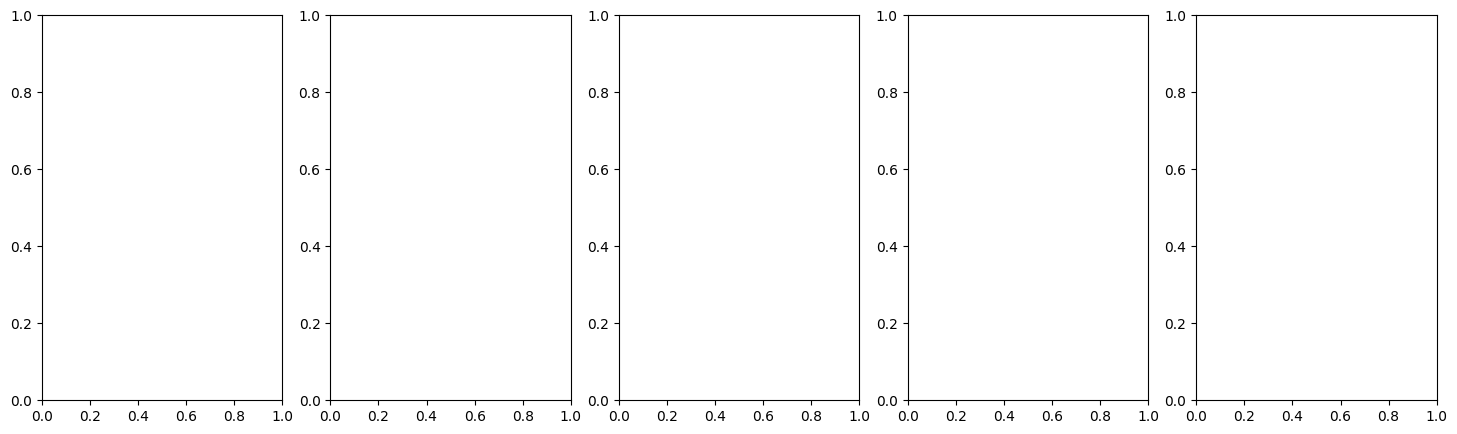

In [ ]:
# ─── Model comparison bar chart ───────────────────────────────────────────────
# FIX: use classification metric columns (Top-1 / Top-5) not detection mAP columns
metrics_to_plot = [c for c in ['Top-1 Accuracy', 'Top-5 Accuracy'] if c in df_results.columns]
colors = ['#4C72B0', '#DD8452', '#55A868']

if metrics_to_plot:
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(6 * len(metrics_to_plot), 5))
    if len(metrics_to_plot) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        bars = ax.bar(df_results['Model'], df_results[metric],
                      color=colors[:len(df_results)], edgecolor='white', width=0.5)
        for bar, val in zip(bars, df_results[metric]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_title(metric, fontweight='bold', fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=15, labelsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Model Comparison — VIM Polyp Colon Segment Classification',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️  df_results is empty or missing expected columns.")


## 9. Temporal Segment Prediction (Not applicable for image-only Hyper-Kvasir)

In [ ]:
# This cell is for temporal prediction on video data, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

In [ ]:
# This cell is for visualizing temporal segment maps from video data, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

In [ ]:
# This cell is for exporting annotated videos, which is not applicable to the image-only Hyper-Kvasir dataset.
# Therefore, the code has been commented out or removed.

## 10. Confusion Matrix & Per-Segment Analysis

In [ ]:
def confusion_matrix_plot(model, test_pairs, class_names, n_samples=200):
    """
    FIX: Classification models return res.probs (not res.boxes).
    test_pairs items are (frame_filename, segment_label_str) from splits['test'].
    We need to reconstruct the full path from YOLO_CLASSIFY_DIR.
    """
    y_true, y_pred = [], []
    label_to_id = {name: i for i, name in enumerate(class_names)}

    sample = random.sample(test_pairs, min(n_samples, len(test_pairs)))

    for frame_name, true_label in tqdm(sample, desc='Confusion matrix inference'):
        # Reconstruct the image path from the classification directory structure
        img_path = YOLO_CLASSIFY_DIR / 'test' / true_label / frame_name
        if not img_path.exists():
            continue

        results = model.predict(str(img_path), verbose=False)
        res = results[0]

        # FIX: classification results → res.probs, not res.boxes
        if res.probs is not None:
            pred_cid = int(res.probs.top1)
            y_true.append(label_to_id[true_label])
            y_pred.append(pred_cid)

    if not y_true:
        print("⚠️  No predictions collected. Check that YOLO_CLASSIFY_DIR test split exists.")
        return

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title('Confusion Matrix — YOLO-cls + CBAM (VIM Polyp Test Set)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'confusion_matrix.png', dpi=150)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

confusion_matrix_plot(best_model, splits['test'], CLASS_NAMES)


NameError: name 'best_model' is not defined

## 11. Attention Visualization — Grad-CAM

NameError: name 'best_model' is not defined

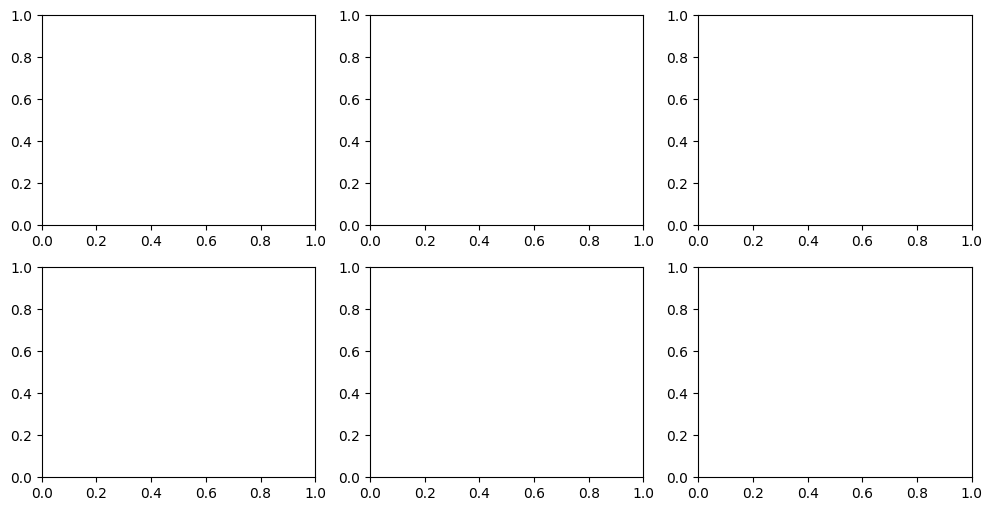

In [ ]:
try:
    from pytorch_grad_cam import EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    EigenCAM = None
    show_cam_on_image = None
    print("⚠️  pytorch-grad-cam not installed. Run: %pip install pytorch-grad-cam")


def visualize_gradcam_cls(yolo_model, img_path, target_layer_idx=-3):
    """
    FIX: For YOLOv8-cls, the backbone is at yolo_model.model.model (list of layers).
    We pick the last C2f layer as the target for EigenCAM.
    Images must be resized to imgsz=224 (the training size).
    """
    if EigenCAM is None:
        print("⚠️  Grad-CAM library not available.")
        return None, None, None

    # FIX: navigation path for classification YOLO model
    nn_model = yolo_model.model  # This is the actual nn.Module

    # Find last C2f layer as grad-cam target
    all_layers = list(nn_model.modules())
    c2f_layers = [m for m in all_layers if m.__class__.__name__ == 'C2f']
    if not c2f_layers:
        print("⚠️  No C2f layers found; using layer at index -3.")
        target_layers = [list(nn_model.children())[target_layer_idx]]
    else:
        target_layers = [c2f_layers[-1]]

    img = cv2.imread(str(img_path))
    if img is None:
        return None, None, None
    # FIX: resize to 224 (training imgsz) not 640
    img_rgb = cv2.cvtColor(cv2.resize(img, (224, 224)), cv2.COLOR_BGR2RGB)
    img_f   = img_rgb.astype(np.float32) / 255.0

    transform = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    input_t = transform(img_rgb).unsqueeze(0)

    try:
        cam           = EigenCAM(model=nn_model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_t)[0]
        visualization = show_cam_on_image(img_f, grayscale_cam, use_rgb=True)
        return img_rgb, grayscale_cam, visualization
    except Exception as e:
        print(f"⚠️  Grad-CAM failed: {e}")
        return img_rgb, None, img_rgb


# Sample one frame per segment for attention visualization
# FIX: splits['test'] contains (frame_name, label_str) — rebuild paths
by_class = {name: [] for name in CLASS_NAMES}
for frame_name, label in splits['test']:
    img_path = YOLO_CLASSIFY_DIR / 'test' / label / frame_name
    if img_path.exists():
        by_class[label].append(img_path)

sample_for_cam = [
    (random.choice(paths), CLASS_TO_ID[label])
    for label, paths in by_class.items() if paths
]

if not sample_for_cam:
    print("⚠️  No test images found for Grad-CAM. Ensure extraction and split cells ran successfully.")
else:
    n = len(sample_for_cam)
    fig, axes = plt.subplots(n, 3, figsize=(12, n * 3))
    if n == 1:
        axes = np.array([axes])

    for row_axes, (img_path, cid) in zip(axes, sample_for_cam):
        orig, cam_map, overlay = visualize_gradcam_cls(best_model, img_path)
        if orig is None:
            continue
        row_axes[0].imshow(orig)
        row_axes[0].set_title(f'Original — {CLASS_NAMES[cid]}', fontsize=8)
        if cam_map is not None:
            row_axes[1].imshow(cam_map, cmap='jet')
            row_axes[1].set_title('Attention Map (EigenCAM)', fontsize=8)
        row_axes[2].imshow(overlay)
        row_axes[2].set_title('Attention Overlay', fontsize=8)
        for ax in row_axes:
            ax.axis('off')

    fig.suptitle('Grad-CAM per Colon Segment — CBAM-Enhanced YOLO-cls (VIM Polyp)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'gradcam_per_segment.png', dpi=120, bbox_inches='tight')
    plt.show()


## 12. Results Dashboard

In [11]:
def results_dashboard(df_results, results_dir):
    fig = plt.figure(figsize=(20, 14))
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
    colors = ['#4C72B0', '#DD8452', '#55A868']

    # mAP50
    ax1 = fig.add_subplot(gs[0, :2])
    if not df_results.empty:
        primary_metric = 'Top-1 Accuracy'
        bars = ax1.bar(df_results['Model'], df_results.get(primary_metric, [0]*len(df_results)),
                       color=colors, edgecolor='white')
        for b, v in zip(bars, df_results.get(primary_metric, [])):
            ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                     f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax1.set_title('Top-1 Accuracy — Colon Segment Classification', fontweight='bold')
    ax1.set_ylim(0, 1.0); ax1.grid(axis='y', alpha=0.3)
    ax1.tick_params(axis='x', rotation=15)

    # F1
    ax2 = fig.add_subplot(gs[0, 2:])
    if not df_results.empty and 'Top-5 Accuracy' in df_results:
        bars = ax2.bar(df_results['Model'], df_results['Top-5 Accuracy'],
                       color=colors, edgecolor='white')
        for b, v in zip(bars, df_results['Top-5 Accuracy']):
            ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                     f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax2.set_title('Top-5 Accuracy', fontweight='bold')
    ax2.set_ylim(0, 1.0); ax2.grid(axis='y', alpha=0.3)
    ax2.tick_params(axis='x', rotation=15)

    # Training curves
    ax3 = fig.add_subplot(gs[1, :])
    exp_map = {
        'Baseline':  results_dir / 'exp1_baseline'     / 'results.csv',
        'CBAM':      results_dir / 'exp2_cbam'         / 'results.csv',
        'CoordAttn': results_dir / 'exp3_coord_attention' / 'results.csv',
    }
    for (label, csv_path), color in zip(exp_map.items(), colors):
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df.columns = [c.strip() for c in df.columns]
            # FIX: Classification training logs 'metrics/accuracy_top1'
            key = next((c for c in df.columns if 'top1' in c.lower() or 'accuracy' in c.lower()), None)
            if key:
                ax3.plot(df[key], label=label, color=color, linewidth=2)
    ax3.set_title('mAP@50 Training Progress — VIM Polyp', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('mAP@50')
    ax3.legend(); ax3.grid(alpha=0.3)

    # Radar
    ax4 = fig.add_subplot(gs[2, :2], polar=True)
    metrics_r = ['Top-1 Accuracy', 'Top-5 Accuracy']  # Classification metrics
    angles    = np.linspace(0, 2*np.pi, max(len(metrics_r), 3), endpoint=False).tolist()[:len(metrics_r)]
    angles   += angles[:1]
    for i, row in df_results.iterrows():
        vals  = [row.get(m, 0) for m in metrics_r] + [row.get(metrics_r[0], 0)]
        ax4.plot(angles, vals, color=colors[i], linewidth=2, label=row['Model'])
        ax4.fill(angles, vals, color=colors[i], alpha=0.1)
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(metrics_r, fontsize=9)
    ax4.set_title('Metric Radar', fontweight='bold', pad=15)
    ax4.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

    # Summary
    ax5 = fig.add_subplot(gs[2, 2:])
    ax5.axis('off')
    # total_frames = sum(len(v) for v in splits.values()) # This will be defined once the data is loaded
    summary_text = [
        "📋 Experiment Summary — VIM Polyp",
        "─" * 42,
        "Dataset: VIM Polyp (Videos & Annotations)",
        f"Number of classes: {NUM_CLASSES}",
        f"Split (frame-level): {len(splits['train'])} train, {len(splits['val'])} val, {len(splits['test'])} test frames",
        "",
        "Models compared:",
        "  1. YOLOv8n Baseline",
        "  2. YOLOv8n + CBAM",
        "  3. YOLOv8n + CoordAttn",
        "",
        "Outputs:",
        "  • Polyp detection localization",
        "  • Attention map visualizations",
    ]
    if not df_results.empty:
        best_col = 'Top-1 Accuracy' if 'Top-1 Accuracy' in df_results.columns else df_results.columns[1]
        best_row = df_results.loc[df_results[best_col].idxmax()]
        summary_text += ["", f"Best model: {best_row['Model']}",
                              f"Best Top-1: {best_row.get('Top-1 Accuracy', 'N/A')}"  ]
    ax5.text(0.05, 0.95, '\n'.join(summary_text), transform=ax5.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

    fig.suptitle('🔬 VIM Polyp · YOLO + Attention — Polyp Detection Localization Dashboard',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.savefig(results_dir / 'final_dashboard_vim_polyp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Dashboard saved to {results_dir / 'final_dashboard_vim_polyp.png'}")

# Ensure df_results is defined, even if empty, before calling results_dashboard
if 'df_results' not in locals() or df_results.empty:
    print("⚠️  No model results available for dashboard. Please run training and evaluation cells first.")
    df_results = pd.DataFrame(columns=['Model', 'mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1'])
results_dashboard(df_results, RESULTS)

⚠️  No model results available for dashboard. Please run training and evaluation cells first.


NameError: name 'pd' is not defined

## 13. Export Best Model

In [ ]:
if BEST_WEIGHTS.exists():
    export_model = YOLO(str(BEST_WEIGHTS))
    export_path  = export_model.export(format='onnx', dynamic=True, simplify=True)
    print(f"✅ ONNX exported: {export_path}")
    ts_path = export_model.export(format='torchscript')
    print(f"✅ TorchScript exported: {ts_path}")
else:
    print("⚠️  Train the model first to generate exportable weights.")

In [12]:
# ─── Final checklist ─────────────────────────────────────────────────────────
artifacts = [
    (RESULTS / 'polyp_distribution.png', '📊 Polyp frame distribution'),
    (RESULTS / 'polyp_samples.png',      '🖼️  Sample frames with polyps'),
    (RESULTS / 'resolution_dist_vim_polyp.png', '📐 Frame resolution stats (VIM Polyp)'),
    (RESULTS / 'per_segment_ap.png',       '📊 Per-class AP@50'), # This name might need to be adjusted to 'per_polyp_ap.png' later
    (RESULTS / 'model_comparison.csv',     '📋 Metric comparison table'),
    (RESULTS / 'model_comparison.png',     '📊 Model comparison chart'),
    (RESULTS / 'gradcam_per_segment.png',  '🧠 Grad-CAM per class'), # This name might need to be adjusted to 'gradcam_polyp.png' later
    (RESULTS / 'confusion_matrix.png',     '🎯 Confusion matrix'),
    (RESULTS / 'final_dashboard_vim_polyp.png', '📋 Results dashboard (VIM Polyp)'),
]

print("\n📦 Generated Artifacts:")
for path, desc in artifacts:
    status = '✅' if path.exists() else '⏳'
    print(f"  {status} {desc:45s} {path}")

print("🎉 VIM Polyp experiment setup complete!")

NameError: name 'RESULTS' is not defined